In [1]:
import pandas as pd

In [2]:
pd.read_parquet("../artifacts/augmented/train_meta_aug.parquet")

,z,z_err,ebv,SpecType,English Translation,split,target,dist_mod
object_id,,,,,,,,
Dornhoth_fervain_onodrim,3.045656,NaN,0.110,AGN,Trawn Folk (Dwarfs) + northern + Ents (people),split_01,0,47.115551
Dornhoth_galadh_ylf,0.446518,NaN,0.058,SN II,Trawn Folk (Dwarfs) + tree + drinking vessel,split_01,0,42.033862
Elrim_melethril_thul,0.468056,NaN,0.577,AGN,Elves + lover (fem.) + breath,split_01,0,42.155497
Ithil_tobas_rodwen,0.697999,NaN,0.012,AGN,moon + roof + noble maiden,split_01,0,43.202088
Mirion_adar_Druadan,0.410608,NaN,0.058,AGN,"jewel, Silmaril + father + Wild Man",split_01,0,41.818404
...,...,...,...,...,...,...,...,...
tinnu_gellui_tathar,0.899443,NaN,0.042,AGN,"dusk, twilight + triumphant + tathar",split_20,0,43.876503
uir_heleg_corf,0.985884,NaN,0.042,AGN,eternity + ice + ring,split_20,0,44.121729
uir_rhosc_law,0.154571,NaN,0.024,SN II,"eternity + russet, red, brown + no! don't!",split_20,0,39.408386


In [3]:
pd.read_parquet("../artifacts/augmented/train_obs_aug.parquet")

,object_id,mjd,flux,flux_err,filter,flux_lupt
0,Dornhoth_fervain_onodrim,63314.4662,-1.711444,0.384016,z,1.673477
1,Dornhoth_fervain_onodrim,63780.9674,11.427573,0.276310,r,-4.042027
2,Dornhoth_fervain_onodrim,63789.7693,6.092316,1.619329,y,-1.508275
3,Dornhoth_fervain_onodrim,63794.1702,4.248717,0.410170,r,-2.548216
4,Dornhoth_fervain_onodrim,63794.1702,5.562850,0.550111,i,-2.522583
...,...,...,...,...,...,...
23514,ylf_alph_mindon,63490.0577,0.104018,0.184234,i,-0.302570
23515,ylf_alph_mindon,63494.7890,0.088351,0.363682,i,-0.131559
23516,ylf_alph_mindon,63530.2733,-0.292466,0.241705,r,0.622249
23517,ylf_alph_mindon,63324.4641,3.333750,1.934058,i,-0.847138


In [4]:
pd.read_parquet("../artifacts/features/train_feats.parquet")

,z,z_err,ebv,target,dist_mod,g_Flux_Mean,g_Flux_Std,g_Flux_Skew,g_Flux_Kurt,g_Flux_Q10,...,z_TDE_ReducedChi2,z_VonNeumannRatio,z_ExcessVariance,z_Likelihood_ReducedChi2_Ratio_TDE_SN,BB_Temp_Mean,BB_Temp_Slope,Color_Slope_g_r,Color_Mean_g_r,AbsMag_Peak_g,AbsMag_Peak_r
object_id,,,,,,,,,,,,,,,,,,,,,
Dornhoth_fervain_onodrim,3.045656,NaN,0.110,0,47.115551,-0.423497,0.768323,1.631871,0.931724,-0.892886,...,NaN,2.055679,32.389105,NaN,20000.0,1.245997e-13,-0.007199,0.848980,-23.332773,-25.860436
Dornhoth_galadh_ylf,0.446518,NaN,0.058,0,42.033862,0.192299,0.386486,1.619346,2.776157,-0.092690,...,NaN,1.051104,6.621766,NaN,20000.0,2.173073e-14,-0.002987,0.823251,-18.446719,-19.228452
Elrim_melethril_thul,0.468056,NaN,0.577,0,42.155497,1.036601,0.826528,0.453294,-1.140555,0.142951,...,NaN,0.927489,0.192101,NaN,20000.0,1.271802e-14,0.000502,0.826871,-19.205002,-19.836704
Ithil_tobas_rodwen,0.697999,NaN,0.012,0,43.202088,0.282278,0.353878,0.534977,0.084505,-0.125576,...,NaN,0.918669,1.014973,NaN,20000.0,1.303997e-14,0.000324,0.324223,-19.657966,-19.989151
Mirion_adar_Druadan,0.410608,NaN,0.058,0,41.818404,0.049306,0.858119,0.269019,-1.148071,-0.862960,...,NaN,0.954006,8.790316,NaN,20000.0,-2.431955e-15,-0.000316,0.104573,-18.415332,-18.892691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tinnu_gellui_tathar,0.899443,NaN,0.042,0,43.876503,0.183744,0.298312,0.333234,-1.375705,-0.153951,...,NaN,0.622610,0.967705,NaN,20000.0,1.174824e-14,-0.000223,0.429511,-19.453617,-20.043745
uir_heleg_corf,0.985884,NaN,0.042,0,44.121729,0.515930,1.889130,-0.283940,-1.479422,-1.836093,...,NaN,1.649678,28.964586,NaN,20000.0,2.915528e-15,-0.000508,-0.434698,-21.313221,-20.940902
uir_rhosc_law,0.154571,NaN,0.024,0,39.408386,0.108475,0.166695,1.252023,1.337149,-0.051251,...,NaN,0.529386,1.576819,NaN,20000.0,2.107891e-15,0.000256,0.606060,-14.883069,-16.355795


In [5]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

# Connect to the EXISTING database and study
# (Do not create a new study, just load it)
study = optuna.load_study(
    study_name="cb_study_20251216-091312-+0000", 
    storage="sqlite:///D:/root/dev/py/mallorn/optuna.db"
)

# These will auto-update every time you re-run the cell
print(f"Current Trials: {len(study.trials)}")
plot_optimization_history(study)

c:\Users\nguye\AppData\Local\pypoetry\Cache\virtualenvs\mallorn-_y-VJO5c-py3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current Trials: 122


In [6]:
plot_param_importances(study)

Retraining model with best params: {'iterations': 2635, 'learning_rate': 0.03040840746522757, 'depth': 6, 'l2_leaf_reg': 9.030745280945847, 'border_count': 237, 'random_strength': 0.3667611006129433, 'bagging_temperature': 0.9446693326462541, 'loss_function': 'Logloss', 'scale_pos_weight': np.float64(19.56081081081081), 'eval_metric': 'AUC', 'verbose': False, 'random_seed': 67, 'allow_writing_files': False}


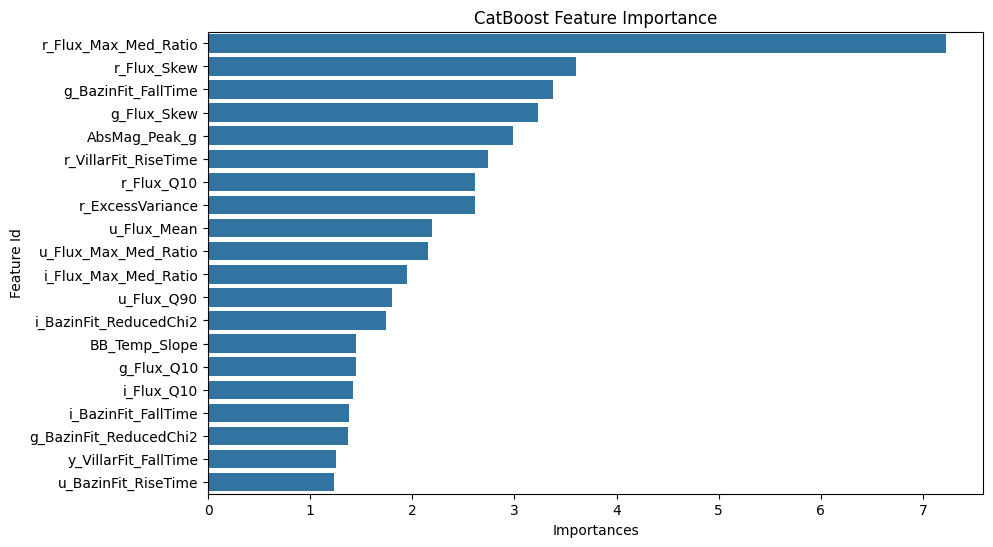

In [9]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from mallorn.common import SEED

# 2. Prepare your data (Make sure X_train/y_train are loaded in your notebook)
feats_df = pd.read_parquet("../artifacts/features/train_feats.parquet")
X_train = feats_df.drop(columns=["target"])
y_train = feats_df["target"]

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos = n_neg / n_pos if n_pos > 0 else 1.0

# 1. Load the Best Parameters from your fixed study
best_params = study.best_params
best_params.update({
    # "task_type": "GPU",
    "loss_function": "Logloss",
    "scale_pos_weight": scale_pos,
    "eval_metric": "AUC",
    "verbose": False,
    "random_seed": SEED,
    "allow_writing_files": False,
})
print(f"Retraining model with best params: {best_params}")

# 3. Retrain the model
# Note: You might need to manually add fixed params that weren't tuned 
# (e.g., iterations, loss_function) if they aren't in best_params.
model = CatBoostClassifier(
    **best_params,
)
model.fit(X_train, y_train)

# 4. Get Feature Importance
importance = model.get_feature_importance(type='FeatureImportance', prettified=True)

# 5. Plotting (Simple Bar Chart)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Importances", y="Feature Id", data=importance.head(20)) # Top 20 features
plt.title('CatBoost Feature Importance')
plt.show()